In [102]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from scipy.io import loadmat

The Korteweg–de Vries (KdV) equation is the PDE:
$$\frac{\partial u}{\partial t} + \lambda_1 u\frac{\partial u}{\partial x} - \lambda_2\frac{\partial^3 u}{\partial x^3} = 0$$
$\lambda_1$ and $\lambda_2$ are the parameters we want to discover.

We'll evolve $u(0,x)$ using Runge-Kutta methods. Let's define $u^{n+c_j}=u(t^n+c_j\Delta t, x)$. Applying an RK method with $q$ stages on the PDE, we get
$$u^{n+1} = u^n - \Delta t \sum_{j=1}^q b_j\left(\lambda_1 u^{n+c_j}u_x^{n+c_j} - \lambda_2 u_{xxx}^{n+c_j}\right)$$
where
$$u^{n+c_i} = u^n - \Delta t \sum_{j=1}^q a_{ij}\left(\lambda_1 u^{n+c_j}u_x^{n+c_j} - \lambda_2 u_{xxx}^{n+c_j}\right)\ \mathrm{where}\ i\in\{1,...,q\}$$

We build a $q$-out dense neural network that, at time $t^n$, does
$$x \mapsto \left[u^{n+c_1}(x),...,u^{n+c_q}(x)\right] \mapsto \left[u_1^n(x),...,u_q^n(x),u_{q+1}^n(x)\right]$$
and
$$x \mapsto \left[u^{n+c_1}(x),...,u^{n+c_q}(x)\right] \mapsto \left[u_1^{n+1}(x),...,u_q^{n+1}(x),u_{q+1}^{n+1}(x)\right]$$

The loss functions are
$$L_n = \sum_{j=1}^{q} \sum_{i=1}^{N_n} |u_j^n(x^{n,i}) - u^{n,i}|^2$$
$$L_{n+1} = \sum_{j=1}^{q} \sum_{i=1}^{N_{n+1}} |u_j^{n+1}(x^{n+1,i}) - u^{n+1,i}|^2$$
$$L_\mathrm{total} = L_n + L_{n+1}$$

In [103]:
file_name = '../data/KdV.mat'
data = loadmat(file_name)

t_star = data['tt'].flatten()[:,None]
x_star = data['x'].flatten()[:,None]
u_star = np.real(data['uu'])

N0 = 199
N1 = 201
idx_t = 40
skip = 120

idx_x = np.random.choice(u_star.shape[0], N0, replace=False)
x0 = x_star[idx_x,:]
u0 = u_star[idx_x,idx_t][:,None]

idx_x = np.random.choice(u_star.shape[0], N1, replace=False)
x1 = x_star[idx_x,:]
u1 = u_star[idx_x,idx_t + skip][:,None]

dt = (t_star[idx_t+skip] - t_star[idx_t]).item()

x0.shape, u0.shape, x1.shape, u1.shape

((199, 1), (199, 1), (201, 1), (201, 1))

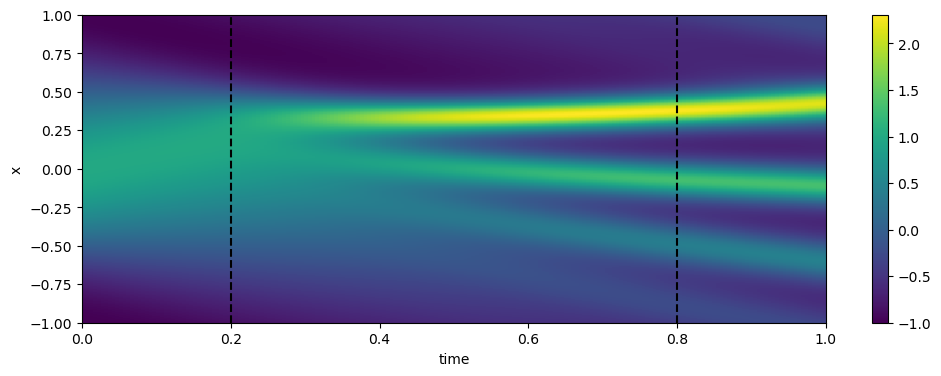

In [104]:
plt.figure(figsize=(12,4))
plt.imshow(data['uu'], origin='lower', aspect='auto', interpolation='none', extent=(0, 1, -1, 1), cmap='viridis')
plt.xlabel('time')
plt.ylabel('x')
plt.axvline(t_star[idx_t], c='k', ls='--')
plt.axvline(t_star[idx_t+skip], c='k', ls='--')
plt.colorbar();

In [105]:
def get_RK_Abc(q):
    tmp = np.float32(np.loadtxt('../data/Butcher_IRK%d.txt' % (q), ndmin = 2))
    IRK_weights = np.reshape(tmp[0:q**2+q], (q+1,q))
    IRK_times = tmp[q**2+q:]
    del tmp
    Ab = tf.convert_to_tensor(IRK_weights, dtype=tf.float32)
    c = tf.convert_to_tensor(IRK_times, dtype=tf.float32)
    return Ab[:-1], Ab[-1], c

In [106]:
class NeuralNetwork:
    def __init__(self, width, depth) -> None:
        self.N0 = 199
        self.N1 = 201
        self.x0 = tf.convert_to_tensor(x0, dtype=tf.float32)  # (N0, 1)
        self.x1 = tf.convert_to_tensor(x1, dtype=tf.float32)  # (N1, 1)
        # self.u0 = self.u_at_t0(self.x0)
        self.u0 = tf.convert_to_tensor(u0, dtype=tf.float32)
        self.u1 = tf.convert_to_tensor(u1, dtype=tf.float32)
        self.dt = dt  # time step
        self.q = 4 #50  # RK stages
        self.model = self.get_model(width, depth)
        self.A, b, _ = get_RK_Abc(self.q)
        self.A_minus_b = self.A - b
        self.lambda_1 = tf.Variable([1.], trainable=True, dtype=tf.float32)
        self.lambda_2 = tf.Variable([-6.], trainable=True, dtype=tf.float32)
    
    def get_model(self, width, depth):
        model = keras.models.Sequential()
        model.add(keras.layers.InputLayer(shape=(1,)))
        for _ in range(depth):
            model.add(keras.layers.Dense(width, activation='tanh'))
        model.add(keras.layers.Dense(self.q, activation=None))
        return model
    
    def u_n_c(self, x):  # (N_n, q)
        return self.model(x)
    
    # def u_grads(self, x):
    #     with tf.autodiff.ForwardAccumulator(
    #         primals=x,
    #         tangents=tf.ones_like(x),
    #     ) as acc_outer:
    #         with tf.autodiff.ForwardAccumulator(
    #             primals=x,
    #             tangents=tf.ones_like(x),
    #         ) as acc_mid:
    #             with tf.autodiff.ForwardAccumulator(
    #                 primals=x,
    #                 tangents=tf.ones_like(x),
    #             ) as acc_inner:
    #                 u = self.u_n_c(x)
    #             u_x = acc_inner.jvp(u)
    #         u_xx = acc_mid.jvp(u_x)
    #     u_xxx = acc_outer.jvp(u_xx)
    #     return u, u_x, u_xxx

    def u_grads(self, x):
        u_x_list, u_xxx_list = [], []
        for i in range(self.q):
            with tf.GradientTape(persistent=False) as tape_out:
                tape_out.watch(x)
                with tf.GradientTape(persistent=False) as tape_mid:
                    tape_mid.watch(x)
                    with tf.GradientTape(persistent=False) as tape_in:
                        tape_in.watch(x)
                        u = self.u_n_c(x)[:, i:i+1]
                    u_x  = tape_in.gradient(u, x)
                u_xx = tape_mid.gradient(u_x, x)
            u_xxx = tape_out.gradient(u_xx, x)
            u_x_list.append(u_x)
            u_xxx_list.append(u_xxx)

        U = self.u_n_c(x)
        U_x = tf.concat(u_x_list, axis=1)
        U_xxx = tf.concat(u_xxx_list, axis=1)

        return U, U_x, U_xxx
    
    def N(self, x):
        # non-linear operator
        u, u_x, u_xxx = self.u_grads(x)
        non_lin = self.lambda_1 * u * u_x + tf.exp(self.lambda_2) * u_xxx
        return u, non_lin

    def u_n_i(self, x, N_coeff):
        u_n_c, non_lin = self.N(x)
        u_n_i = u_n_c + self.dt * tf.matmul(non_lin, N_coeff, transpose_b=True)
        return u_n_c, u_n_i
    
    # def u_at_t0(self, x):
    #     u = np.cos(np.pi * x).astype(np.float32)
    #     return tf.convert_to_tensor(u, dtype=tf.float32)

    def get_loss(self, x0, x1):
        _, u_n_i_0 = self.u_n_i(x0, self.A)
        _, u_n_i_1 = self.u_n_i(x1, self.A_minus_b)

        # sum dimension order doesn't matter
        loss_0 = tf.reduce_mean(tf.square(u_n_i_0 - self.u0))
        loss_1 = tf.reduce_mean(tf.square(u_n_i_1 - self.u1))

        loss = loss_0 + loss_1
        return loss, loss_0, loss_1

    @tf.function
    def train_step(self, optimizer):
        with tf.GradientTape() as tape:
            loss, loss_0, loss_1 = self.get_loss(self.x0, self.x1)
        variables_to_train = self.model.trainable_variables
        grads = tape.gradient(loss, variables_to_train)
        optimizer.apply_gradients(zip(grads, variables_to_train))
        return loss, loss_0, loss_1
    
    @tf.function
    def train_step_joint(self, optimizer):
        with tf.GradientTape() as tape:
            loss, loss_0, loss_1 = self.get_loss(self.x0, self.x1)
        variables_to_train = self.model.trainable_variables + [self.lambda_1, self.lambda_2]
        grads = tape.gradient(loss, variables_to_train)
        optimizer.apply_gradients(zip(grads, variables_to_train))
        return loss, loss_0, loss_1
    
    def show_state(self, title=''):
        unc_0, uni_0 = self.u_n_i(tf.convert_to_tensor(np.linspace(-1, 1, self.N0), dtype=tf.float32)[:,None], self.A)
        unc_1, uni_1 = self.u_n_i(tf.convert_to_tensor(np.linspace(-1, 1, self.N1), dtype=tf.float32)[:,None], self.A_minus_b)
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='tight')
        for i, (ax, u) in enumerate(zip(axes.flatten(), [unc_0, uni_0, unc_1, uni_1])):
            im = ax.imshow(u, origin='lower', aspect='auto', interpolation='none', extent=(0, 1, -1, 1), cmap='viridis')
            plt.colorbar(im)
        axes[0,0].set_ylabel('initial x')
        axes[1,0].set_ylabel('final x')
        axes[1,0].set_xlabel('time increment')
        axes[1,1].set_xlabel('stage')
        fig.suptitle(title)
        return fig, ax

In [107]:
neural_network = NeuralNetwork(width=50, depth=3)
_ = neural_network.model(neural_network.x0)

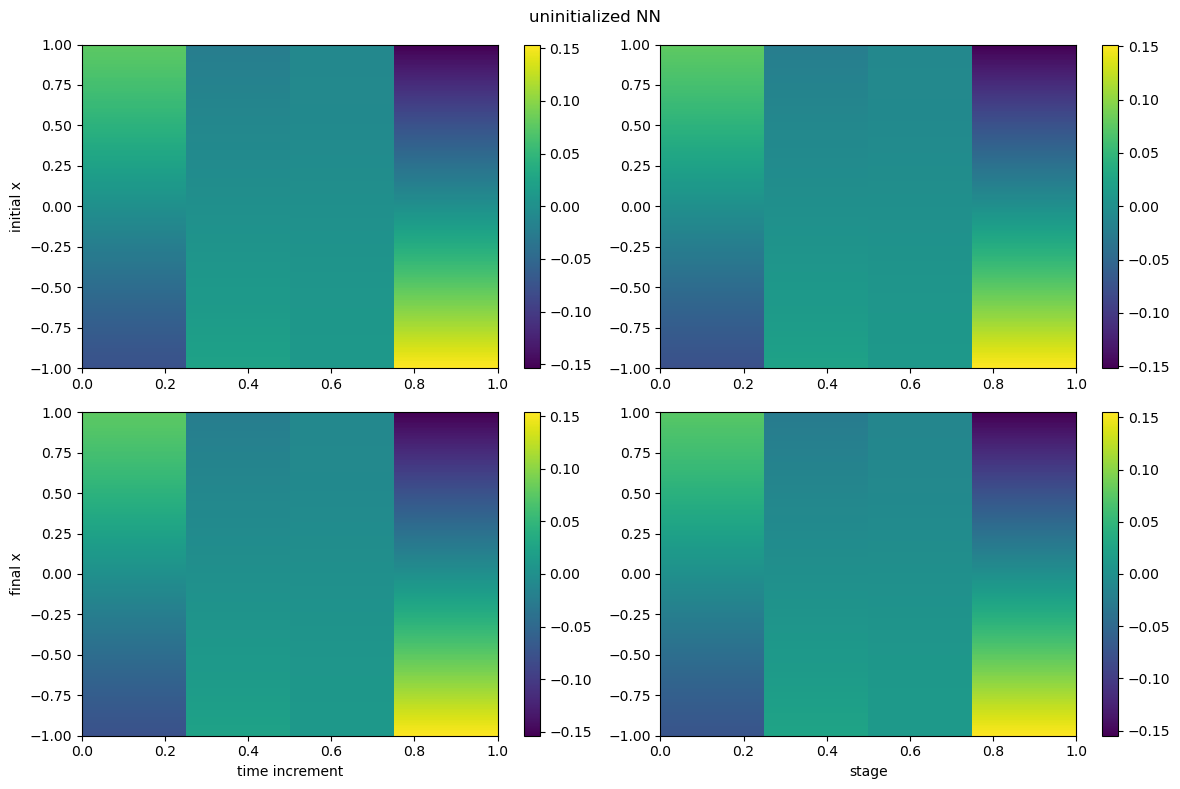

In [108]:
neural_network.show_state("uninitialized NN");

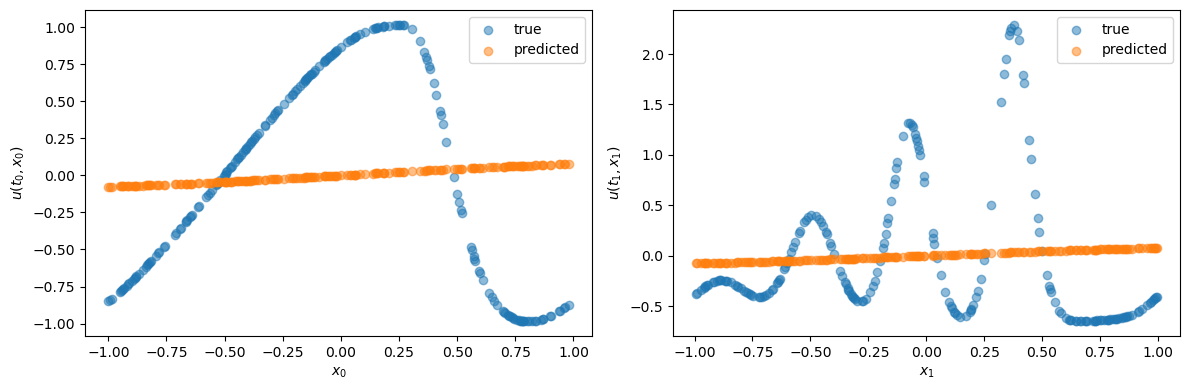

In [109]:
u_n_c_0 = neural_network.u_n_c(neural_network.x0)
u_n_c_1 = neural_network.u_n_c(neural_network.x1)

fig, ax = plt.subplots(1, 2, figsize=(12,4), layout='tight')
ax[0].scatter(neural_network.x0, neural_network.u0, alpha=0.5, label="true")
ax[0].scatter(neural_network.x0, u_n_c_0[:,0], alpha=0.5, label="predicted")
ax[0].set_xlabel('$x_0$')
ax[0].set_ylabel('$u(t_0,x_0)$')
ax[0].legend()
ax[1].scatter(neural_network.x1, neural_network.u1, alpha=0.5, label="true")
ax[1].scatter(neural_network.x1, u_n_c_1[:,0], alpha=0.5, label="predicted")
ax[1].set_xlabel('$x_1$')
ax[1].set_ylabel('$u(t_1,x_1)$')
ax[1].legend();

In [110]:
# optimizer = keras.optimizers.SGD(learning_rate=0.02)
optimizer = keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.)
neural_network.model.compile(optimizer)

In [111]:
EPOCHS = 10_000
history = {"loss": [], "loss_0": [], "loss_1": [], "lambda_1": [], "lambda_2": []}
for epoch in range(1, EPOCHS + 1):
    # loss, loss_0, loss_1 = neural_network.train_step(optimizer)
    loss, loss_0, loss_1 = neural_network.train_step_joint(optimizer)
    history["loss"].append(float(loss))
    history["loss_0"].append(float(loss_0))
    history["loss_1"].append(float(loss_1))
    history["lambda_1"].append(float(neural_network.lambda_1))
    history["lambda_2"].append(float(neural_network.lambda_2))
    if epoch % 500 == 0 or epoch == 1:
        print(f"epoch {epoch:5d} | loss {loss:.4e} | loss_0 {loss_0:.2e} | loss_1 {loss_1:.2e} | lambda_1 {float(neural_network.lambda_1):.2e} | log_lambda_2 {float(neural_network.lambda_2):.2e}")
    if epoch % 2000 == 0:
        new_LR = optimizer.learning_rate.numpy() / 2
        optimizer.learning_rate.assign(new_LR)

epoch     1 | loss 9.7201e-01 | loss_0 4.83e-01 | loss_1 4.89e-01 | lambda_1 1.00e+00 | log_lambda_2 -6.00e+00
epoch   500 | loss 4.0599e-02 | loss_0 6.76e-03 | loss_1 3.38e-02 | lambda_1 9.44e-01 | log_lambda_2 -5.91e+00
epoch  1000 | loss 1.5514e-02 | loss_0 2.81e-03 | loss_1 1.27e-02 | lambda_1 9.89e-01 | log_lambda_2 -5.92e+00
epoch  1500 | loss 9.7836e-03 | loss_0 1.66e-03 | loss_1 8.12e-03 | lambda_1 1.00e+00 | log_lambda_2 -5.93e+00
epoch  2000 | loss 8.4323e-03 | loss_0 1.23e-03 | loss_1 7.21e-03 | lambda_1 1.00e+00 | log_lambda_2 -5.94e+00
epoch  2500 | loss 7.7223e-03 | loss_0 1.09e-03 | loss_1 6.63e-03 | lambda_1 1.00e+00 | log_lambda_2 -5.94e+00
epoch  3000 | loss 7.0206e-03 | loss_0 9.59e-04 | loss_1 6.06e-03 | lambda_1 1.01e+00 | log_lambda_2 -5.94e+00
epoch  3500 | loss 6.5046e-03 | loss_0 8.62e-04 | loss_1 5.64e-03 | lambda_1 1.01e+00 | log_lambda_2 -5.94e+00
epoch  4000 | loss 6.1235e-03 | loss_0 8.10e-04 | loss_1 5.31e-03 | lambda_1 1.01e+00 | log_lambda_2 -5.94e+00
e

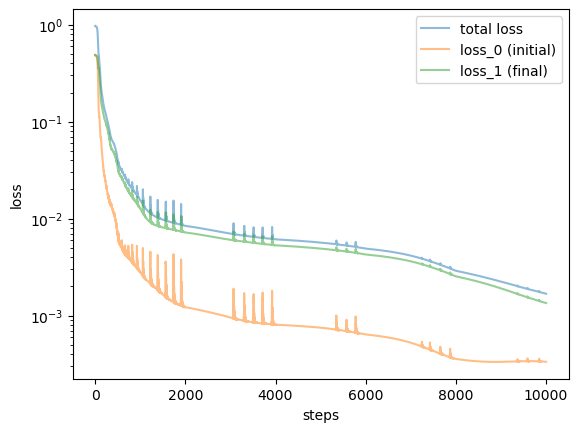

In [112]:
plt.yscale('log')
plt.plot(history['loss'], alpha=0.5, label='total loss')
plt.plot(history['loss_0'], alpha=0.5, label='loss_0 (initial)')
plt.plot(history['loss_1'], alpha=0.5, label='loss_1 (final)')
plt.xlabel('steps')
plt.ylabel('loss')
plt.legend();

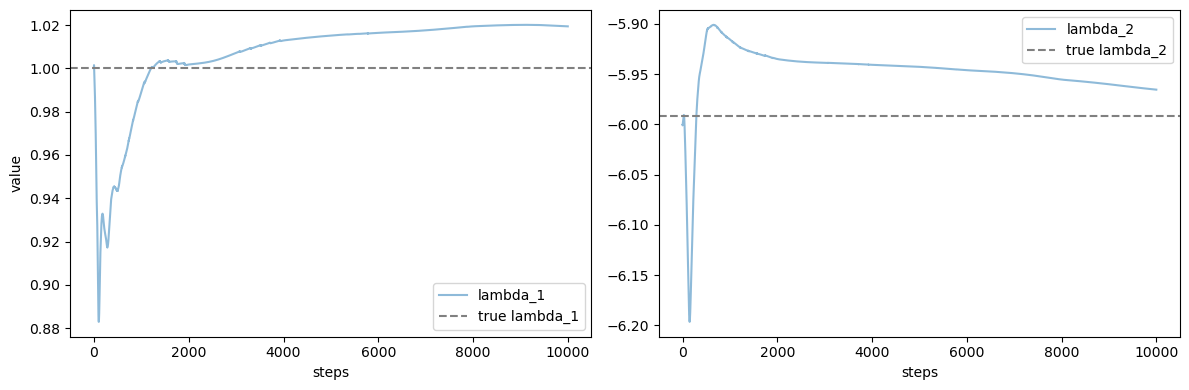

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='tight')
for ax, l_n, true_value in zip(axes, ['1', '2'], [1., np.log(0.0025)]):
    ax.plot(history['lambda_'+l_n], alpha=0.5, label='lambda_'+l_n)
    ax.axhline(true_value, c='gray', ls='--', label="true lambda_"+l_n)
    ax.set_xlabel('steps')
    ax.legend()
axes[0].set_ylabel('value');

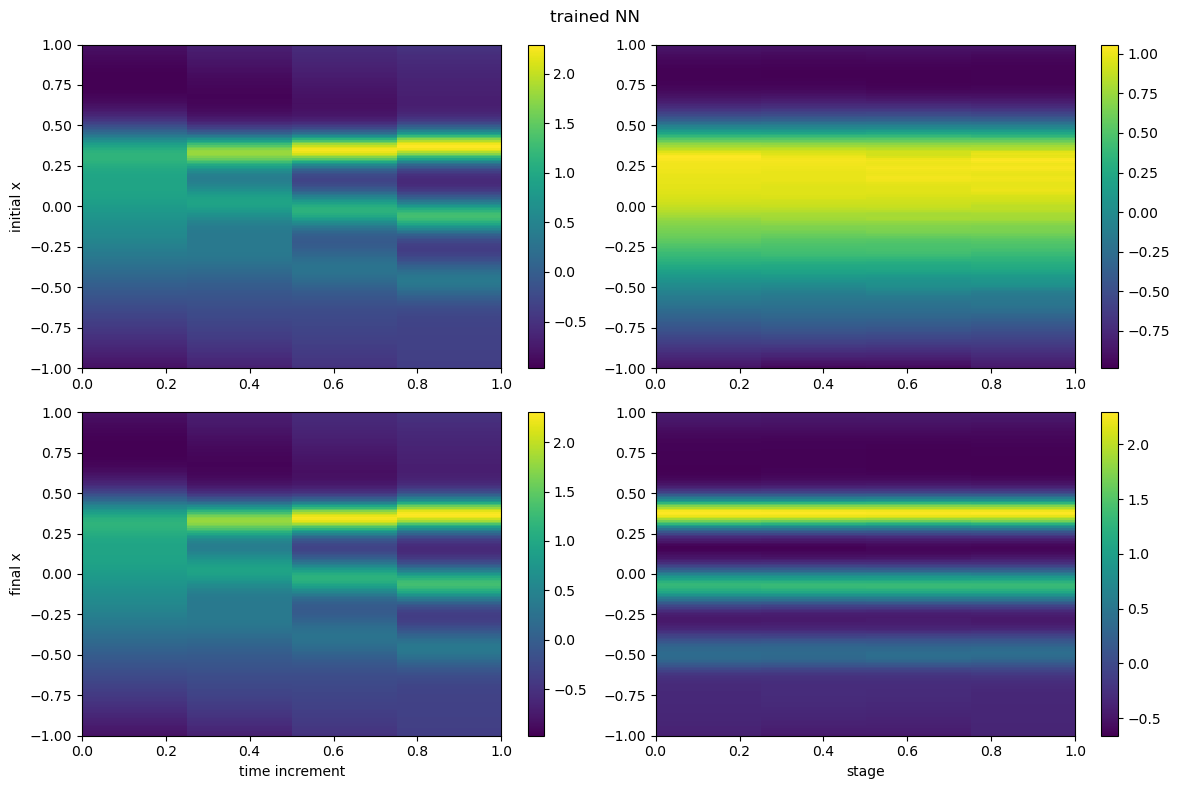

In [114]:
neural_network.show_state("trained NN");

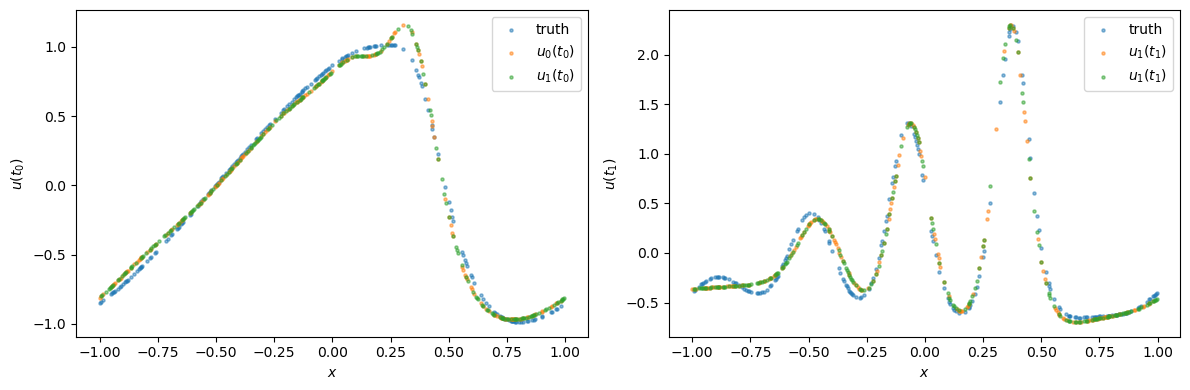

In [115]:
u_n_c_0 = neural_network.u_n_c(neural_network.x0)
u_n_c_1 = neural_network.u_n_c(neural_network.x1)

fig, ax = plt.subplots(1, 2, figsize=(12,4), layout='tight')
ax[0].scatter(neural_network.x0, neural_network.u0, s=5., alpha=0.5, label="truth")
ax[0].scatter(neural_network.x0, u_n_c_0[:,0], s=5., alpha=0.5, label=r"$u_0(t_0)$")
ax[0].scatter(neural_network.x1, u_n_c_1[:,0], s=5., alpha=0.5, label=r"$u_1(t_0)$")
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('$u(t_0)$')
ax[0].legend()

ax[1].scatter(neural_network.x1, neural_network.u1, s=5., alpha=0.5, label="truth")
ax[1].scatter(neural_network.x0, u_n_c_0[:,-1], s=5., alpha=0.5, label=r"$u_1(t_1)$")
ax[1].scatter(neural_network.x1, u_n_c_1[:,-1], s=5., alpha=0.5, label=r"$u_1(t_1)$")
ax[1].set_xlabel('$x$')
ax[1].set_ylabel('$u(t_1)$')
ax[1].legend();